# mycx_1000 ML training workbench

This notebook is the first visual Phase 2 entry point.
It is designed to be safe on first run: it checks local cache, auto-prepares cache when needed, then runs offline replay training.


In [25]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "config.py").exists():
    candidates = [REPO_ROOT.parent, REPO_ROOT.parent.parent]
    for candidate in candidates:
        if (candidate / "config.py").exists():
            REPO_ROOT = candidate
            break

if not (REPO_ROOT / "config.py").exists():
    raise RuntimeError("Could not locate repo root. Open the notebook from the mycx_1000 workspace.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT


WindowsPath('d:/self-work/mycx_1000')

In [26]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

from config import DEFAULT_CONFIG
import tuner.data_cache as data_cache_mod
import tuner.offline_evaluator as offline_evaluator_mod
import tuner.train as train_mod

# Force reload so the notebook is safe even if this kernel imported old tuner modules earlier.
data_cache_mod = importlib.reload(data_cache_mod)
offline_evaluator_mod = importlib.reload(offline_evaluator_mod)
train_mod = importlib.reload(train_mod)

CACHE_ROOT = data_cache_mod.CACHE_ROOT
cache_historical_events = data_cache_mod.cache_historical_events
OfflineEvaluator = offline_evaluator_mod.OfflineEvaluator
build_snapshot_plan = train_mod.build_snapshot_plan
run_training = train_mod.run_training
split_event_ids = train_mod.split_event_ids
split_formal_event_ids = train_mod.split_formal_event_ids
split_formal_training_event_ids = train_mod.split_formal_training_event_ids

plt.style.use("ggplot")


## 1. Configure the workbench

If cache is empty or not large enough, the notebook will auto-fetch history snapshots.


In [27]:
CACHE_DIR = CACHE_ROOT
HISTORY_COUNT = 100
MIN_ELIGIBLE_EVENTS = 12
MIN_TEST_EVENTS = 4
SNAPSHOT_PROGRESS_BUCKETS = [
    (0.15, 0.25),
    (0.25, 0.40),
    (0.40, 0.55),
    (0.55, 0.70),
    (0.70, 0.85),
]
SNAPSHOT_SAMPLES_PER_BUCKET = 1
SNAPSHOT_SEED = 42
PREPARE_CACHE = False
REFRESH_CACHE = False
TRAIN_LIMIT = None
TEST_LIMIT = None

# Training runtime controls
MAXITER = 16
POPSIZE = 12
VERBOSE_TRAIN = True
LOG_EVERY_EVALS = 20
TRAIN_WORKERS = -1  # Fastest for long runs, but Windows/Jupyter multiprocessing can be less stable.
USE_GPU = False  # Current run_training path is CPU-only.
CURVE_SAMPLE_COUNT = 3
CURVE_LOSS_WEIGHT = 0.10

BASE_CONFIG = DEFAULT_CONFIG.copy()
BASE_CONFIG["similar_count"] = 5
BASE_CONFIG["ignore_event_ids"] = list(DEFAULT_CONFIG["ignore_event_ids"])

# Formal training defaults:
# - Deterministic random snapshots instead of a few fixed debug hours
# - Full eligible train/test slices unless you explicitly cap them
# - Curve auxiliary loss enabled to regularize the future trajectory shape


In [28]:
def compute_eligible_event_ids(evaluator, similar_count, ignore_ids):
    if hasattr(evaluator, "eligible_event_ids"):
        return evaluator.eligible_event_ids(similar_count=similar_count, ignore_ids=ignore_ids)

    # Compatibility fallback for stale kernels or partially reloaded modules.
    eligible = []
    for event_id in evaluator.available_event_ids():
        cached_event = evaluator.cached_events[event_id]
        event_type = cached_event.get("event_type") or cached_event.get("meta", {}).get("event_type", "unknown")
        history_ids = evaluator._select_history_event_ids(
            target_event_id=event_id,
            event_type=event_type,
            count=similar_count,
            ignore_ids=ignore_ids,
        )
        if len(history_ids) >= similar_count:
            eligible.append(event_id)
    return eligible

def load_cache_state():
    evaluator = OfflineEvaluator.from_cache_dir(cache_root=CACHE_DIR)
    event_ids = evaluator.available_event_ids()
    eligible_ids = compute_eligible_event_ids(
        evaluator,
        similar_count=BASE_CONFIG["similar_count"],
        ignore_ids=BASE_CONFIG.get("ignore_event_ids", []),
    )
    return evaluator, event_ids, eligible_ids

evaluator, event_ids, eligible_ids = load_cache_state()
need_prepare = PREPARE_CACHE or len(eligible_ids) < MIN_ELIGIBLE_EVENTS

if need_prepare:
    cache_summary = cache_historical_events(
        history_count=HISTORY_COUNT,
        cache_root=CACHE_DIR,
        refresh=REFRESH_CACHE,
        api_source=BASE_CONFIG["api_source"],
    )
    evaluator, event_ids, eligible_ids = load_cache_state()
else:
    cache_summary = {
        "cache_root": str(CACHE_DIR),
        "prepared": False,
        "cached_events": len(event_ids),
        "eligible_events": len(eligible_ids),
    }

cache_summary


{'cache_root': 'D:\\self-work\\mycx_1000\\tuner\\data',
 'prepared': False,
 'cached_events': 139,
 'eligible_events': 109}

In [29]:
train_ids, test_ids, external_holdout_ids = split_formal_training_event_ids(
    eligible_ids,
    train_ratio=0.75,
    evaluator=evaluator,
    min_test_events=MIN_TEST_EVENTS,
    min_event_id=200,
    train_max_event_id=300,
    holdout_min_event_id=301,
)

if TRAIN_LIMIT is not None:
    train_ids = train_ids[-int(TRAIN_LIMIT):]
if TEST_LIMIT is not None:
    test_ids = test_ids[:int(TEST_LIMIT)]

train_snapshot_plan = build_snapshot_plan(
    evaluator,
    train_ids,
    seed=SNAPSHOT_SEED,
    progress_buckets=SNAPSHOT_PROGRESS_BUCKETS,
    samples_per_bucket=SNAPSHOT_SAMPLES_PER_BUCKET,
)
test_snapshot_plan = build_snapshot_plan(
    evaluator,
    test_ids,
    seed=SNAPSHOT_SEED + 9973,
    progress_buckets=SNAPSHOT_PROGRESS_BUCKETS,
    samples_per_bucket=SNAPSHOT_SAMPLES_PER_BUCKET,
)
external_holdout_snapshot_plan = build_snapshot_plan(
    evaluator,
    external_holdout_ids,
    seed=SNAPSHOT_SEED + 19973,
    progress_buckets=SNAPSHOT_PROGRESS_BUCKETS,
    samples_per_bucket=SNAPSHOT_SAMPLES_PER_BUCKET,
)

print(f"cached events: {len(event_ids)}")
print(f"eligible events: {len(eligible_ids)}")
print(f"snapshot buckets: {SNAPSHOT_PROGRESS_BUCKETS}")
print(f"train snapshots: {sum(len(v) for v in train_snapshot_plan.values())} | validation snapshots: {sum(len(v) for v in test_snapshot_plan.values())}")
print(f"external holdout snapshots: {sum(len(v) for v in external_holdout_snapshot_plan.values())}")
print(f"formal split: train/validation<=300, external holdout>=301")
print(f"train ids: {len(train_ids)} | validation ids: {len(test_ids)} | external holdout ids: {len(external_holdout_ids)}")

if len(train_ids) < 1 or len(test_ids) < 1:
    raise RuntimeError(
        "Not enough train/test events for validation. Increase HISTORY_COUNT or lower BASE_CONFIG['similar_count']."
    )

{
    "eligible_preview": eligible_ids[:10],
    "train_snapshot_example": {event_id: train_snapshot_plan[event_id] for event_id in train_ids[:2]},
    "test_snapshot_example": {event_id: test_snapshot_plan[event_id] for event_id in test_ids[:2]},
    "external_holdout_snapshot_example": {event_id: external_holdout_snapshot_plan[event_id] for event_id in external_holdout_ids[:2]},
}

cached events: 139
eligible events: 109
snapshot buckets: [(0.15, 0.25), (0.25, 0.4), (0.4, 0.55), (0.55, 0.7), (0.7, 0.85)]
train snapshots: 365 | validation snapshots: 125
external holdout snapshots: 25
formal split: train/validation<=300, external holdout>=301
train ids: 73 | validation ids: 25 | external holdout ids: 5


{'eligible_preview': [188, 191, 193, 197, 198, 199, 200, 201, 203, 204],
 'train_snapshot_example': {200: [40.5, 56.25, 94.0, 116.5, 127.0],
  201: [44.0, 64.75, 92.25, 101.25, 136.75]},
 'test_snapshot_example': {276: [40.0, 59.75, 87.5, 121.25, 143.0],
  277: [36.0, 63.5, 106.25, 127.0, 147.75]},
 'external_holdout_snapshot_example': {301: [47.5,
   84.5,
   95.75,
   133.75,
   183.75],
  302: [37.5, 84.75, 121.0, 143.5, 171.25]}}

## 2. Baseline snapshot

Inspect the default config before optimization.


In [30]:
baseline_metrics = evaluator.evaluate(
    BASE_CONFIG,
    event_ids=test_ids if test_ids else train_ids,
    snapshot_plan=test_snapshot_plan if test_ids else train_snapshot_plan,
)

baseline_df = pd.DataFrame(baseline_metrics["rows"])
baseline_df.head()


,event_id,event_type,debug_hours,observed_hours,history_ids,predicted_final,actual_final,abs_error,rel_error,log_error,curve_check_hours,curve_relative_mse,ratio,scale_factor
0,276,mission_live,40.00,39.751667,"[273, 271, 267, 259, 255]",1.654891e+07,24082750.0,-7.533839e+06,-0.312831,-0.375175,[],None,2.199274,0.824725
1,276,mission_live,59.75,59.252222,"[273, 271, 267, 259, 255]",2.685564e+07,24082750.0,2.772887e+06,0.115140,0.108980,[],None,2.452332,1.255459
2,276,mission_live,87.50,87.252500,"[273, 271, 267, 259, 255]",2.429813e+07,24082750.0,2.153777e+05,0.008943,0.008903,[],None,2.580579,1.058257
3,276,mission_live,121.25,120.751667,"[273, 271, 267, 259, 255]",2.246785e+07,24082750.0,-1.614904e+06,-0.067056,-0.069411,[],None,2.731943,0.992983
4,276,mission_live,143.00,142.750278,"[273, 271, 267, 259, 255]",2.249287e+07,24082750.0,-1.589875e+06,-0.066017,-0.068297,[],None,2.906430,0.924383


In [31]:
baseline_metrics


{'count': 124,
 'relative_mse': 0.027928339247027666,
 'log_mse': 0.02834986425312791,
 'rmse': 1947757.521937196,
 'mape': 0.1269489148872656,
 'curve_relative_mse': None,
 'objective_loss': 0.027928339247027666,
 'rows': [{'event_id': 276,
   'event_type': 'mission_live',
   'debug_hours': 40.0,
   'observed_hours': 39.751666666666665,
   'history_ids': [273, 271, 267, 259, 255],
   'predicted_final': 16548911.001241747,
   'actual_final': 24082750.0,
   'abs_error': -7533838.998758253,
   'rel_error': -0.31283134188405615,
   'log_error': -0.3751754985454383,
   'curve_check_hours': [],
   'curve_relative_mse': None,
   'ratio': 2.1992742817896307,
   'scale_factor': 0.8247249591329792},
  {'event_id': 276,
   'event_type': 'mission_live',
   'debug_hours': 59.75,
   'observed_hours': 59.25222222222222,
   'history_ids': [273, 271, 267, 259, 255],
   'predicted_final': 26855636.735571925,
   'actual_final': 24082750.0,
   'abs_error': 2772886.7355719246,
   'rel_error': 0.1151399543

## 3. Run a small training pass

Start small, confirm the loop works, then scale `maxiter` and `popsize` up.


In [32]:
snapshot_plan = {}
snapshot_plan.update(train_snapshot_plan)
snapshot_plan.update(test_snapshot_plan)

result = run_training(
    cache_root=CACHE_DIR,
    prepare_cache=False,
    train_ids=train_ids,
    test_ids=test_ids,
    snapshot_plan=snapshot_plan,
    snapshot_progress_buckets=SNAPSHOT_PROGRESS_BUCKETS,
    snapshot_samples_per_bucket=SNAPSHOT_SAMPLES_PER_BUCKET,
    history_count=HISTORY_COUNT,
    min_test_events=MIN_TEST_EVENTS,
    use_formal_holdout_split=True,
    formal_min_event_id=200,
    formal_train_max_event_id=300,
    formal_holdout_min_event_id=301,
    external_holdout_ids=external_holdout_ids,
    external_holdout_snapshot_plan=external_holdout_snapshot_plan,
    curve_sample_count=CURVE_SAMPLE_COUNT,
    curve_loss_weight=CURVE_LOSS_WEIGHT,
    maxiter=MAXITER,
    popsize=POPSIZE,
    seed=SNAPSHOT_SEED,
    base_config=BASE_CONFIG,
    output_preset_path=REPO_ROOT / "configs" / "models" / "skeleton_kf" / "learned_notebook.json",
    verbose=VERBOSE_TRAIN,
    log_every_n_evals=LOG_EVERY_EVALS,
    workers=TRAIN_WORKERS,
    use_gpu=USE_GPU,
)

baseline_test_mse = None if result["baseline_test"] is None else result["baseline_test"]["relative_mse"]
learned_test_mse = None if result["test_metrics"] is None else result["test_metrics"]["relative_mse"]
external_holdout_mse = None if result.get("external_holdout_metrics") is None else result["external_holdout_metrics"]["relative_mse"]
generalization_delta = None if baseline_test_mse is None or learned_test_mse is None else (learned_test_mse - baseline_test_mse)
generalization_ok = None if generalization_delta is None else (generalization_delta <= 0.0)

{
    "preset_path": result["preset_path"],
    "report_path": result["report_path"],
    "runtime_sec": result.get("runtime_sec"),
    "train_relative_mse": result["train_metrics"]["relative_mse"],
    "train_curve_relative_mse": result["train_metrics"].get("curve_relative_mse"),
    "baseline_test_relative_mse": baseline_test_mse,
    "learned_test_relative_mse": learned_test_mse,
    "learned_test_curve_relative_mse": None if result["test_metrics"] is None else result["test_metrics"].get("curve_relative_mse"),
    "external_holdout_relative_mse": external_holdout_mse,
    "external_holdout_curve_relative_mse": None if result.get("external_holdout_metrics") is None else result["external_holdout_metrics"].get("curve_relative_mse"),
    "generalization_delta": generalization_delta,
    "generalization_ok": generalization_ok,
}


[train] start tier=1 seed=42 maxiter=16 popsize=12 workers=-1 fallback_debug_hours=[24.0, 48.0, 72.0] curve_samples=3 curve_weight=0.1
[train] eval_mode=snapshot_plan baseline train_mse=0.069537 test_mse=0.027928 baseline_curve=0.026687801657879463 train_snapshots=365
[train] generation_done evals=144 best_loss=0.072229 convergence=0.381632
[train] generation_done evals=288 best_loss=0.072229 convergence=0.463448
[train] generation_done evals=432 best_loss=0.071953 convergence=0.584842
[train] generation_done evals=576 best_loss=0.071953 convergence=0.617850
[train] generation_done evals=720 best_loss=0.071953 convergence=0.634211
[train] generation_done evals=864 best_loss=0.071640 convergence=0.772828
[train] generation_done evals=1008 best_loss=0.071640 convergence=0.905263
[train] generation_done evals=1152 best_loss=0.071640 convergence=0.956541
[train] generation_done evals=1296 best_loss=0.071640 convergence=1.235098
[train] done in 3155.3s | train_mse=0.069611 test_mse=0.027545

{'preset_path': 'd:\\self-work\\mycx_1000\\configs\\models\\skeleton_kf\\learned_notebook.json',
 'report_path': 'D:\\self-work\\mycx_1000\\tuner\\reports\\train_20260331_235852.json',
 'runtime_sec': 3155.3106923103333,
 'train_relative_mse': 0.06961061749150925,
 'train_curve_relative_mse': 0.026550399434962416,
 'baseline_test_relative_mse': 0.027928339247027666,
 'learned_test_relative_mse': 0.027544676629880242,
 'learned_test_curve_relative_mse': 0.01406275186061852,
 'external_holdout_relative_mse': 0.0596162744168503,
 'external_holdout_curve_relative_mse': 0.026386442004521227,
 'generalization_delta': -0.00038366261714742333,
 'generalization_ok': True}

## 4. Plot optimizer history


In [33]:
history_rows = result.get("objective_history") or result.get("generation_history") or []
history_df = pd.DataFrame(history_rows)

if history_df.empty:
    print("No optimizer history rows captured.")
elif not {"iteration", "loss"}.issubset(history_df.columns):
    print(f"History columns missing: {list(history_df.columns)}")
else:
    history_df[["iteration", "loss"]].head()

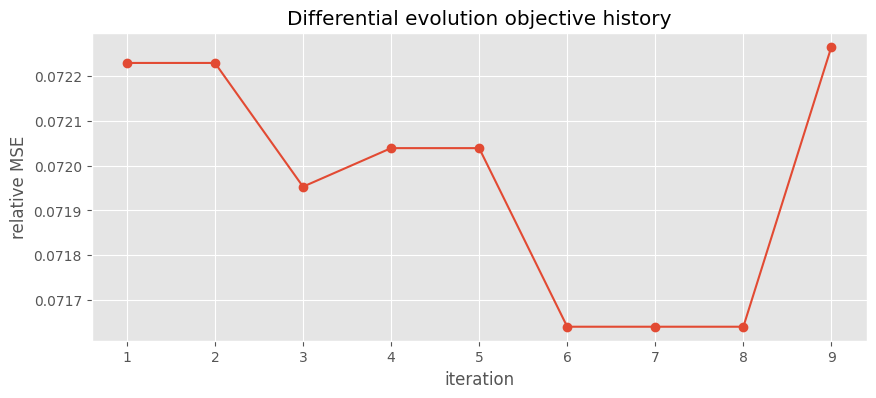

In [34]:
if history_df.empty or not {"iteration", "loss"}.issubset(history_df.columns):
    print("Skip plot: optimizer history is empty or missing required columns.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history_df["iteration"], history_df["loss"], marker="o", linewidth=1.5)
    ax.set_title("Differential evolution objective history")
    ax.set_xlabel("iteration")
    ax.set_ylabel("relative MSE")
    plt.show()

## 5. Compare learned preset on the test slice


In [35]:
test_rows = pd.DataFrame((result["test_metrics"] or {"rows": []})["rows"])
test_rows = test_rows.sort_values("rel_error", key=lambda s: s.abs(), ascending=False)
test_rows.head(10)


,event_id,event_type,debug_hours,observed_hours,history_ids,predicted_final,actual_final,abs_error,rel_error,log_error,curve_check_hours,curve_relative_mse,ratio,scale_factor
115,299,challenge,60.25,59.750278,"[293, 289, 284, 281, 270]",1.014178e+07,6474074.0,3.667707e+06,0.566522,0.448858,"[109.5, 134.5, 189.5]",0.172837,0.726338,1.123983
50,286,mission_live,31.50,31.250278,"[283, 279, 276, 273, 271]",9.532770e+06,19112298.0,-9.579528e+06,-0.501223,-0.695597,"[51.75, 94.5, 125.25]",0.208006,1.162100,0.500000
89,294,medley,33.50,33.251111,"[287, 272, 264, 260, 254]",2.978587e+06,2054820.0,9.237673e+05,0.449561,0.371261,"[79.0, 130.0, 160.75]",0.090075,0.710352,1.138022
85,293,challenge,78.75,78.250556,"[289, 284, 281, 270, 266]",9.306147e+06,6510161.0,2.795986e+06,0.429480,0.357311,"[105.25, 160.25, 187.5]",0.065959,0.585131,0.958042
94,295,live_try,30.25,29.751389,"[292, 285, 282, 280, 277]",5.148188e+06,8350917.0,-3.202729e+06,-0.383518,-0.483727,"[55.0, 104.25, 126.5]",0.046969,1.054817,0.773170
60,288,festival,27.25,26.752500,"[261, 256, 243, 237, 210]",4.401323e+06,7084806.0,-2.683483e+06,-0.378766,-0.476047,"[46.0, 75.5, 97.0]",0.019370,1.863908,0.948779
84,293,challenge,50.00,49.752500,"[289, 284, 281, 270, 266]",8.784754e+06,6510161.0,2.274593e+06,0.349391,0.299654,"[77.75, 147.75, 189.0]",0.033479,0.563857,0.920344
105,297,mission_live,89.25,88.751944,"[291, 286, 283, 279, 276]",3.544013e+07,26516353.0,8.923777e+06,0.336539,0.290083,"[113.5, 136.75, 186.25]",0.051259,1.689463,0.856373
0,276,mission_live,40.00,39.751667,"[273, 271, 267, 259, 255]",1.646355e+07,24082750.0,-7.619204e+06,-0.316376,-0.380347,"[95.0, 105.25, 143.25]",0.049771,2.228027,0.811541
55,287,medley,27.50,27.250556,"[272, 264, 260, 254, 249]",1.399437e+06,1957725.0,-5.582885e+05,-0.285172,-0.335713,"[47.5, 87.25, 105.5]",0.009814,0.920214,0.985381


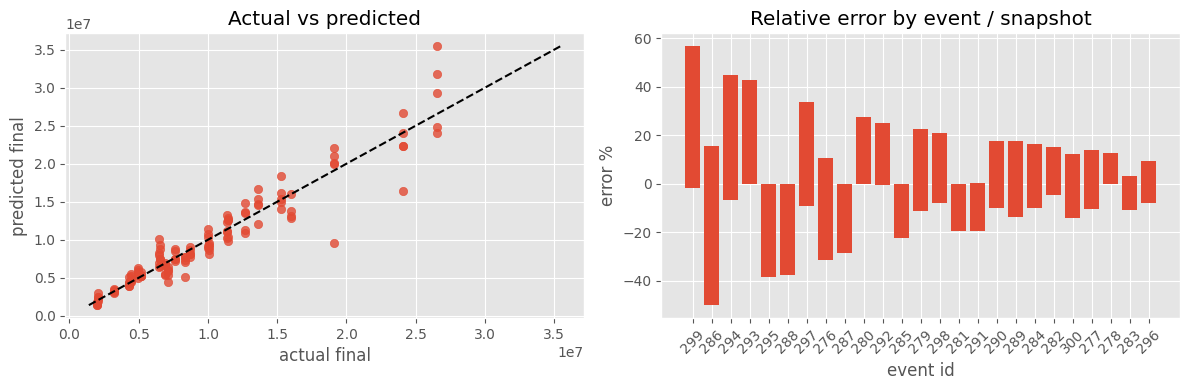

In [36]:
if not test_rows.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(test_rows["actual_final"], test_rows["predicted_final"], alpha=0.8)
    diagonal = [
        test_rows[["actual_final", "predicted_final"]].min().min(),
        test_rows[["actual_final", "predicted_final"]].max().max(),
    ]
    axes[0].plot(diagonal, diagonal, linestyle="--", color="black")
    axes[0].set_title("Actual vs predicted")
    axes[0].set_xlabel("actual final")
    axes[0].set_ylabel("predicted final")

    axes[1].bar(test_rows["event_id"].astype(str), test_rows["rel_error"] * 100.0)
    axes[1].set_title("Relative error by event / snapshot")
    axes[1].set_xlabel("event id")
    axes[1].set_ylabel("error %")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No test rows available. Increase HISTORY_COUNT or lower similar_count.")
